In [1]:
import math, os

import numpy as np
import jax
from jax import Array
from jax import numpy as jnp
from jax import scipy as jsp
import matplotlib.pyplot as plt

import dynamiqs as dq

from blueprint.qubits import TunableTransmon, KerrOscillator, HarmonicOscillator
from blueprint.devices import Device
from blueprint.pulses import flux_pulses, coupler_pulses, charge_pulses
from blueprint.pulses.flux_pulses import net_zero_transition_flux_pulse
from blueprint.operators.basis import OperatorBasis
from blueprint.util.operators import get_pauli_ops
from blueprint.metrics import gate_fidelity

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.90"  # for 90% of total GPU memory

# jax.config.update("jax_default_device", jax.devices("cpu")[0])
jax.config.update("jax_default_device", jax.devices("cuda")[0])
jax.config.update("jax_enable_x64", True)  # Double
dtype = jnp.complex128
# jax.config.update("jax_enable_x64", False)  # Simple
# dtype = jnp.complex64

/home/gene2902/blueprint-env/lib/python3.11/site-packages/qutip/__init__.py:66: UserWarning: The new version of Cython, (>= 3.0.0) is not supported.
  warnings.warn(


In [2]:
# units
kHz, MHz, GHz = 1e-6, 1e-3, 1
ns, us, ms = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi

## Qubits

In [3]:
LABEL = "Q1"
CHARGING_ENERGY = 0.17874386390652913 * GHz
JOSEPHSON_ENERGY = 28.045385714769342 * GHz
ASYMMETRY = 0.617379794210013
CHARGE_CUTOFF = 100
OFFSET_CHARGE = 0.0
EXT_FLUX = 0.0
dim = 20

transmon_1 = TunableTransmon(
    label=LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    relax_time=None,
    deph_time=None,
)

transmon_1.diagonalize(dim)

LABEL = "Q2"
CHARGING_ENERGY = 0.1706758643430758 * GHz
JOSEPHSON_ENERGY = 27.770515104169455 * GHz
ASYMMETRY = 0.5487079408012716
CHARGE_CUTOFF = 100
OFFSET_CHARGE = 0.0
EXT_FLUX = math.pi / 2
# dim = 8

transmon_2 = TunableTransmon(
    label=LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    relax_time=None,
    deph_time=None,
)

transmon_2.diagonalize(dim)

In [4]:
transmon_1.frequency, transmon_2.frequency

(Array(6.14852788, dtype=float64), Array(4.38356101, dtype=float64))

## Device

In [5]:
device = Device(
    [
        transmon_1,
        transmon_2,
    ]
)

In [6]:
# Manually find g0 such as to produce the experimentally measured ZZ
from scipy.optimize import minimize

alpha_ZZ = -8 * kHz
nominal_J1 = 7 * MHz

n_1 = device["Q1"].get_charge_op()
n_2 = device["Q2"].get_charge_op()
coupling_op = jnp.matmul(n_1, n_2)
static_hamiltonian = device.get_bare_hamiltonian()

# TODO: In the future, should use the gradients from JAX directly and do gradient descent (Adam/BFGS).
def cost_func(x,):
    full_hamil = static_hamiltonian + x * coupling_op
    eigvals = jsp.linalg.eigh(full_hamil, eigvals_only=True)
    norm_vals = eigvals - eigvals[0]
    ZZ = norm_vals[4] - norm_vals[2] - norm_vals[1]
    return (ZZ - alpha_ZZ)**2

x0 = (
    nominal_J1
    / abs(float(device["Q1"].charge_zpf))
    / abs(float(device["Q2"].charge_zpf))
)

optim_res = minimize(
    cost_func,
    x0=x0,
)
print(optim_res)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.6133089369166403e-11
        x: [ 3.769e-03]
      nit: 0
      jac: [ 5.122e-08]
 hess_inv: [[1]]
     nfev: 2
     njev: 1


We simply to have enough precision on the 8e-6 to make a better fit of g0 than simply the nominal 7MHz / n1_zpf / n2_zpf.

Should be fine for now

In [7]:
g0 = optim_res.x
g0 / MHz

array([3.76875866])

In [8]:
# g0 = nominal_J1 / abs(float(transmon_1.charge_zpf)) / abs(float(transmon_2.charge_zpf))
device.add_capacative_coupling(
    qubits=("Q1", "Q2"),
    label="C_Q1_Q2",
    prefactor=g0,
)

In [9]:
device.index_eigenstates()

device.diagonalize()

# Drives

In [10]:
# device["Q1"].add_flux_drive(
#     label="flux_Q1_cz_Q1_Q2", flux_pulse=flux_pulses.net_zero_transition_flux_pulse
# )
device["Q1"].add_flux_drive(
    label="flux_Q1_cz_Q1_Q2", flux_pulse=flux_pulses.net_zero_transition_flux_pulse_batchable_voltage
)
device["Q2"].add_flux_drive(
    label="flux_Q2_cz_Q1_Q2", flux_pulse=flux_pulses.net_zero_transition_flux_pulse
)

In [11]:
# device["Q1"].drives["flux_Q1_cz_Q1_Q2"].set_params(
#     # hold_first_voltage=-0.255,
#     transition_voltage=0.0,
#     half_hold_time=65.15 * 1 / 2,
#     transition_time=2.414131062723352,
#     buffer_start=1.9349107142857144e1,
#     buffer_end=1.9349107142857144e1,
#     flux_per_volt=3.1372549019607843,  # 9.817191999999999,  # free parameter that we want to optimize
#     gaussian_filter_sigma=0.5,
# )

device["Q2"].drives["flux_Q2_cz_Q1_Q2"].set_params(
    hold_first_voltage=0.4163522432365655,
    transition_voltage=0.0,
    half_hold_time=65.15 * 1 / 2 * ns,
    transition_time=2.414131062723352 * ns,
    buffer_start=1.9349107142857144e1 * ns,
    buffer_end=1.9349107142857144e1 * ns,
    flux_per_volt=1.9214499573272414,  # 9.90753,  # free parameter that we want to optimize
    gaussian_filter_sigma=0.5,
)

# Build the time-dependent Hamiltonians

In [12]:
dq_static_hamiltonian = dq.constant(device.get_hamiltonian())
dq_static_hamiltonian.shape

(400, 400)

## Let's scan only the voltages on the first qubit for now

In [16]:
for prefactor, op in device["Q2"]._drives["flux_Q2_cz_Q1_Q2"].decompose():
    print(op.round(3), op.shape)
    print(op.shape)
    print(device["Q2"].process_op(op).shape)
    print(device.process_op(device["Q2"].process_op(op)).shape)

[[0. +0.j 0.5+0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0.5+0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 ...
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0.5+0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0.5+0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0.5+0.j 0. +0.j]] (201, 201)
(201, 201)
(400, 400)
(400, 400)
[[0.+0.j  0.+0.5j 0.+0.j  ... 0.+0.j  0.+0.j  0.+0.j ]
 [0.-0.5j 0.+0.j  0.+0.5j ... 0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.j  0.-0.5j 0.+0.j  ... 0.+0.j  0.+0.j  0.+0.j ]
 ...
 [0.+0.j  0.+0.j  0.+0.j  ... 0.+0.j  0.+0.5j 0.+0.j ]
 [0.+0.j  0.+0.j  0.+0.j  ... 0.-0.5j 0.+0.j  0.+0.5j]
 [0.+0.j  0.+0.j  0.+0.j  ... 0.+0.j  0.-0.5j 0.+0.j ]] (201, 201)
(201, 201)
(400, 400)
(400, 400)


In [18]:
voltages_q1 = jnp.linspace(0.1, 0.5, 21)

# Ideally, would use a util function here that loops over all device Drives and Couplings.
# I.e. `device.get_drive_hamiltonian_terms()`.
# For now, just do it manually so that the scan works as intended with dynamiqs batching.
for prefactor, op in device["Q2"]._drives["flux_Q2_cz_Q1_Q2"].decompose():
    dq_hamiltonian = dq_static_hamiltonian + dq.modulated(
        prefactor, device.process_op(device["Q2"].process_op(op)), #args=(,)
    )

for prefactor, op in device["Q1"]._drives["flux_Q1_cz_Q1_Q2"].decompose():
    dq_hamiltonian = dq_hamiltonian + dq.modulated(
        prefactor,
        device.process_op(device["Q1"].process_op(op)),
        args=(
            voltages_q1,
            0.0,  # transition_voltage
            65.15 * 1 / 2 * ns,  # half_hold_time
            2.414131062723352 * ns,  # transition_time
            1.9349107142857144e1 * ns,  # buffer_start
            1.9349107142857144e1 * ns,  # buffer_end
            3.1372549019607843,  # flux_per_volt, free parameter that we want to optimize
            0.5,  # gaussian_filter_sigma
        ),  # Here works directly because this is the first arg of the prefactor function
    )

In [19]:
dq_hamiltonian(30.0*ns).shape

(21, 400, 400)

In [36]:
jnp.diag(dq_hamiltonian(0.0)[0]).real[:10]

Array([-4.65501220e-06,  4.38352417e+00,  6.14854645e+00,  8.57891797e+00,
        1.05320633e+01,  1.21052842e+01,  1.25710252e+01,  1.47274488e+01,
        1.63394751e+01,  1.64887839e+01], dtype=float64)

In [37]:
jnp.diag(device.get_bare_hamiltonian()).real[:10]

Array([ 0.        ,  4.38352883,  6.14855111,  8.57892263, 10.53206792,
       12.10528886, 12.57102988, 14.72745349, 16.33947977, 16.48878858],      dtype=float64)

In [38]:
(
    jnp.diag(dq_hamiltonian(0.0)[0]).real[:10]
    - jnp.diag(device.get_bare_hamiltonian()).real[:10]
)

Array([-4.65501220e-06, -4.65501221e-06, -4.65501219e-06, -4.65501221e-06,
       -4.65501219e-06, -4.65501220e-06, -4.65501224e-06, -4.65501220e-06,
       -4.65501219e-06, -4.65501218e-06], dtype=float64)

In [20]:
voltages_q1

Array([0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 , 0.22, 0.24, 0.26, 0.28, 0.3 ,
       0.32, 0.34, 0.36, 0.38, 0.4 , 0.42, 0.44, 0.46, 0.48, 0.5 ],      dtype=float64)

## Look at the instantanious eigenergies to see if the gate is working as intended

In [21]:
tsave = jnp.linspace(0*ns, 100*ns, 101)
batch_idx = 7
all_eigvals = [] #= jnp.zeros((len(tsave), device.dim))
for tidx, t in enumerate(tsave):
    hamil = dq_hamiltonian(t)[batch_idx]  # to remove the batch dimension from voltages_q1
    eigvals = jsp.linalg.eigh(hamil, eigvals_only=True)
    norm_vals = eigvals - eigvals[0]
    # all_eigvals.at[tidx, :].set(norm_vals)
    all_eigvals.append(norm_vals)
all_eigvals = jnp.array(all_eigvals)

In [22]:
all_eigvals.shape

(101, 400)

In [23]:
from blueprint.util.index import state_index
state_index((1, 1), device.qubit_dims)

21

In [24]:
state_index((1, 0), device.qubit_dims)

20

In [25]:
device.qubit_dims

(20, 20)

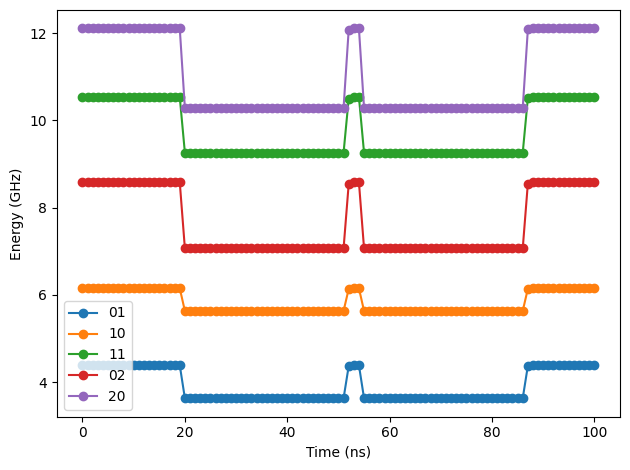

In [26]:
# plt.plot(
#     tsave / ns,
#     all_eigvals[:, device._eig_inds[state_index((0, 0), device.qubit_dims)]],
#     "-o",
#     label="00",
# )
plt.plot(
    tsave / ns,
    all_eigvals[:, device._eig_inds[state_index((0, 1), device.qubit_dims)]],
    "-o",
    label="01",
)
plt.plot(
    tsave / ns,
    all_eigvals[:, device._eig_inds[state_index((1, 0), device.qubit_dims)]],
    "-o",
    label="10",
)
plt.plot(
    tsave / ns,
    all_eigvals[:, device._eig_inds[state_index((1, 1), device.qubit_dims)]],
    "-o",
    label="11",
)
plt.plot(
    tsave / ns,
    all_eigvals[:, device._eig_inds[state_index((0, 2), device.qubit_dims)]],
    "-o",
    label="02",
)
plt.plot(
    tsave / ns,
    all_eigvals[:, device._eig_inds[state_index((2, 0), device.qubit_dims)]],
    "-o",
    label="20",
)
# plt.plot(tsave / ns, all_eigvals[:, device._eig_inds[0]], "-o", label="11")
plt.legend()
plt.xlabel("Time (ns)")
plt.ylabel("Energy (GHz)")
plt.tight_layout()

# TODO: Q2 (01) should be going up in frequency because it's biased at lower sweet spot

In [23]:
all_eigvals[:, device._eig_inds[state_index((0, 1), device.qubit_dims)]]

Array([4.38352883, 4.38352883, 4.38352883, 4.38352883, 4.38352883,
       4.38352883, 4.38352883, 4.38352883, 4.38352883, 4.38352883,
       4.38352883, 4.38352883, 4.38352883, 4.38352883, 4.38352883,
       4.38352883, 4.38352883, 4.38352883, 4.38352883, 4.38352883,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788103,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788103,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788103,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788103,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788103,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788103,
       3.62788103, 3.62788103, 4.36235455, 4.38352883, 4.38352883,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788103,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788103,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788103,
       3.62788103, 3.62788103, 3.62788103, 3.62788103, 3.62788

# Test lower sweet-spot transmon

In [32]:
LABEL = "Q2"
CHARGING_ENERGY = 0.1706758643430758 * GHz
JOSEPHSON_ENERGY = 27.770515104169455 * GHz
ASYMMETRY = 0.5487079408012716
CHARGE_CUTOFF = 100
OFFSET_CHARGE = 0.0
EXT_FLUX = math.pi / 2
dim = 20

In [33]:
num_points = 201
flux_bound = math.pi
fluxes = np.linspace(-flux_bound, flux_bound, num_points)


def flux_pulse(applied_flux: float) -> Array:
    return jnp.array([applied_flux])

In [34]:
charge_dim = 2 * CHARGE_CUTOFF + 1
exact_drive_evals = np.zeros((num_points, charge_dim))

fluxed_transmon = TunableTransmon(
    label=LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
)
static_hamiltonian = fluxed_transmon.get_hamiltonian()

fluxed_transmon.add_flux_drive("flux_drive", flux_pulse)

for ind, flux in enumerate(fluxes):
    drive_hamiltonian = fluxed_transmon.get_drive_hamiltonian(applied_flux=flux)
    full_hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    exact_drive_evals[ind] = norm_energies

In [40]:
fluxed_transmon._drives["flux_drive"].get_hamiltonian(applied_flux=flux).shape

(20, 20)

In [41]:
charge_dim = 2 * CHARGE_CUTOFF + 1
approx_drive_evals = np.zeros((num_points, dim))

fluxed_transmon = TunableTransmon(
    label=LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
)
fluxed_transmon.diagonalize(dim)
static_hamiltonian = fluxed_transmon.get_hamiltonian()

fluxed_transmon.add_flux_drive("flux_drive", flux_pulse)

for ind, flux in enumerate(fluxes):
    # drive_hamiltonian = fluxed_transmon.get_drive_hamiltonian(applied_flux=flux)
    drive_hamiltonian = fluxed_transmon._drives["flux_drive"].get_hamiltonian(applied_flux=flux)
    full_hamiltonian = static_hamiltonian + drive_hamiltonian
    energies = jsp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_energies = energies - energies[0]
    approx_drive_evals[ind] = norm_energies

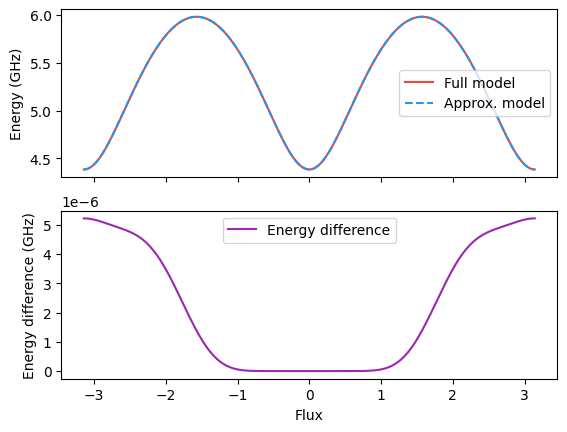

In [42]:
state = 1

exact_energies = exact_drive_evals[:, state]
approx_energies = approx_drive_evals[:, state]

fig, (comp_ax, diff_ax) = plt.subplots(nrows=2, sharex=True)

comp_ax.plot(fluxes, exact_energies, color="#f44336", label=f"Full model")
comp_ax.plot(
    fluxes, approx_energies, color="#2196f3", linestyle="--", label=f"Approx. model"
)

comp_ax.legend()
comp_ax.set_ylabel("Energy (GHz)")


energy_diff = np.abs(exact_energies - approx_energies)
diff_ax.plot(fluxes, energy_diff, color="#9c27b0", label=f"Energy difference")

diff_ax.legend()
diff_ax.set_xlabel("Flux")
diff_ax.set_ylabel("Energy difference (GHz)")

plt.show()

In [51]:
for prefactor, op in device["Q1"]._drives["flux_Q1_cz_Q1_Q2"].decompose():
    print(op.round(3))

[[ 0.944+0.j  0.   +0.j  0.   +0.j ... -0.   +0.j -0.   +0.j -0.   +0.j]
 [ 0.   +0.j  0.944+0.j  0.   +0.j ... -0.   +0.j -0.   +0.j -0.   +0.j]
 [ 0.   +0.j  0.   +0.j  0.944+0.j ... -0.   +0.j -0.   +0.j -0.   +0.j]
 ...
 [-0.   +0.j -0.   +0.j -0.   +0.j ... -0.101+0.j -0.   +0.j -0.   +0.j]
 [-0.   +0.j -0.   +0.j -0.   +0.j ... -0.   +0.j -0.101+0.j -0.   +0.j]
 [-0.   +0.j -0.   +0.j -0.   +0.j ... -0.   +0.j -0.   +0.j -0.101+0.j]]
[[0.-0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.-0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.-0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


In [46]:
for prefactor, op in device["Q2"]._drives["flux_Q2_cz_Q1_Q2"].decompose():
    print(op.round(3))

[[ 0.+0.j     0.+0.364j  0.+0.j    ...  0.-0.j     0.+0.j     0.+0.j   ]
 [ 0.-0.364j  0.-0.j     0.+0.482j ...  0.+0.j     0.+0.j     0.+0.j   ]
 [ 0.-0.j     0.-0.482j  0.+0.j    ...  0.-0.j     0.+0.j    -0.+0.j   ]
 ...
 [-0.+0.j     0.+0.j    -0.+0.j    ... -0.-0.j    -0.+0.j    -0.-0.352j]
 [ 0.+0.j     0.+0.j     0.+0.j    ... -0.-0.j    -0.-0.j    -0.-0.352j]
 [ 0.+0.j     0.+0.j     0.-0.j    ... -0.+0.352j -0.+0.352j  0.+0.j   ]]
[[ 0.925+0.j -0.   -0.j  0.103-0.j ...  0.   -0.j -0.   +0.j  0.   +0.j]
 [-0.   +0.j  0.775-0.j -0.   -0.j ...  0.   -0.j  0.   +0.j  0.   +0.j]
 [ 0.103+0.j -0.   +0.j  0.625-0.j ...  0.   -0.j -0.   +0.j  0.   +0.j]
 ...
 [-0.   +0.j -0.   +0.j -0.   +0.j ... -0.07 +0.j -0.   -0.j -0.353+0.j]
 [ 0.   -0.j  0.   +0.j  0.   -0.j ... -0.   +0.j -0.07 +0.j -0.352+0.j]
 [ 0.   +0.j  0.   +0.j  0.   +0.j ... -0.353-0.j -0.352-0.j -0.056-0.j]]


In [49]:
drive_hamiltonian = fluxed_transmon._drives["flux_drive"].get_hamiltonian(
    applied_flux=flux
)
print(drive_hamiltonian.round(3))

[[ 2.8194e+01+0.j -0.0000e+00+0.j  3.1250e+00-0.j -0.0000e+00-0.j
   2.3200e-01-0.j  0.0000e+00+0.j -2.4000e-02+0.j -0.0000e+00+0.j
  -4.0000e-03+0.j  0.0000e+00+0.j -1.0000e-03-0.j -0.0000e+00+0.j
   0.0000e+00-0.j -0.0000e+00-0.j -0.0000e+00-0.j  0.0000e+00-0.j
   0.0000e+00-0.j -0.0000e+00-0.j -0.0000e+00+0.j  0.0000e+00-0.j]
 [-0.0000e+00-0.j  2.3625e+01-0.j -0.0000e+00+0.j  5.2880e+00+0.j
  -0.0000e+00+0.j -5.4700e-01-0.j -0.0000e+00-0.j -7.5000e-02+0.j
  -0.0000e+00+0.j -1.4000e-02-0.j  0.0000e+00-0.j  2.0000e-03+0.j
  -0.0000e+00-0.j -0.0000e+00-0.j  0.0000e+00-0.j  0.0000e+00-0.j
  -0.0000e+00-0.j -0.0000e+00-0.j  0.0000e+00-0.j  0.0000e+00-0.j]
 [ 3.1250e+00+0.j -0.0000e+00-0.j  1.9034e+01-0.j -0.0000e+00+0.j
   7.2820e+00+0.j -0.0000e+00-0.j -1.0030e+00-0.j  0.0000e+00+0.j
  -1.9400e-01-0.j -0.0000e+00+0.j -7.1000e-02-0.j  0.0000e+00-0.j
   1.2000e-02-0.j -0.0000e+00-0.j -1.0000e-03-0.j  0.0000e+00-0.j
   0.0000e+00-0.j -0.0000e+00-0.j -0.0000e+00+0.j  0.0000e+00-0.j]
 [ 0.00

# Everything looks fine here, problem must be with the device object op processing